In [ ]:
import torch, torchvision, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader
import json, datetime
from collections import Counter
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
from torchvision.models import ResNet18_Weights
import torchvision.transforms as transforms
import torch.nn as nn
import datetime
SEED = 1
torch.manual_seed(SEED); np.random.seed(SEED)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_full_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [ ]:
all_labels = train_full_dataset.targets.numpy()

train_indices, val_indices = train_test_split(
    np.arange(len(train_full_dataset)),
    test_size=0.3,
    random_state=SEED,
    stratify=all_labels
)

train_dataset_70 = Subset(train_full_dataset, train_indices)
val_dataset_30   = Subset(train_full_dataset, val_indices)

train_labels = all_labels[train_indices]
val_labels   = all_labels[val_indices]
print("cell3")

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        def forward_hook(module, input, output):
            self.activations = output
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]
        self.f_handle = target_layer.register_forward_hook(forward_hook)
        self.b_handle = target_layer.register_full_backward_hook(backward_hook)
    def generate(self, input_tensor, target_class=None):
        with torch.set_grad_enabled(True):
            self.model.eval()

            logits = self.model(input_tensor)
            if target_class is None:
                target_class = logits.argmax(dim=1).item()

            self.model.zero_grad()

            one_hot = torch.zeros_like(logits)
            one_hot[0, target_class] = 1.0

            logits.backward(gradient=one_hot)

        # 2. Формула (2): α_k^c
        alpha = torch.mean(self.gradients, dim=(2, 3))

        # 3. Формула (3): L^c = ReLU(Σ α * A)
        cam = torch.relu((alpha.unsqueeze(2).unsqueeze(3) * self.activations).sum(dim=1))

        cam_min, cam_max = cam.min(), cam.max()
        if cam_max - cam_min > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = torch.zeros_like(cam)

        cam_resized = F.interpolate(
            cam.unsqueeze(0),
            size=input_tensor.shape[2:],
            mode='bilinear',
            align_corners=False
        )

        return cam_resized.squeeze().detach().cpu().numpy(), target_class

In [ ]:
def calculate_fidelity(model, images, masks, target_classes):
    #Fidelity = f(x_i) - f(x_i ⊙ m_i)
    model.eval()
    device = images.device

    masks_exp = masks.unsqueeze(1).to(device)
    masked_images = images * masks_exp  # x_i ⊙ m_i

    with torch.no_grad():
        logits_orig = model(images)
        logits_masked = model(masked_images)

    idx = torch.arange(len(target_classes), device=device)
    fidelity_scores = logits_orig[idx, target_classes] - logits_masked[idx, target_classes]

    return fidelity_scores.mean().item(), fidelity_scores.cpu().numpy()

def calculate_stability(model, target_layer, images, epsilon=0.05, n_perturbations=5):
    image_scores = []

    for img in images:
        gradcam = GradCAM(model, target_layer)

        img_orig = img.clone().detach().requires_grad_(True)
        orig_mask, _ = gradcam.generate(img_orig.unsqueeze(0))

        gradcam.f_handle.remove()
        gradcam.b_handle.remove()

        perturb_dists = []
        for _ in range(n_perturbations):
            gradcam = GradCAM(model, target_layer)  # свежие хуки для каждого perturbation

            noise = torch.randn_like(img) * epsilon
            perturbed = (img + noise).detach().requires_grad_(True)
            pert_mask, _ = gradcam.generate(perturbed.unsqueeze(0))

            gradcam.f_handle.remove()
            gradcam.b_handle.remove()
            orig_mask = orig_mask.astype(np.float32)
            pert_mask = pert_mask.astype(np.float32)
            dist = np.sqrt(np.mean((orig_mask - pert_mask) ** 2) + 1e-10)
            perturb_dists.append(dist)

        image_scores.append(np.mean(perturb_dists))

    return np.mean(image_scores)

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
model.fc = nn.Linear(model.fc.in_features, 10)

for param in model.parameters():
    param.requires_grad = False
for param in list(model.conv1.parameters()) + list(model.fc.parameters()):
    param.requires_grad = True

model = model.to(device)

generator = torch.Generator().manual_seed(SEED)
train_loader_70 = DataLoader(
    train_dataset_70,
    batch_size=64,
    shuffle=True,
    generator=generator,
    num_workers=0
)
sample_indices = np.random.choice(len(train_dataset_70), size=20, replace=False)

metric_loader = DataLoader(
    Subset(train_dataset_70, sample_indices),
    batch_size=20,
    shuffle=False,
    num_workers=0
)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
criterion = nn.CrossEntropyLoss()

stage1_logs = []
NUM_EPOCHS = 6
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_70:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Epoch {epoch}/{NUM_EPOCHS} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}")
    if epoch % 2 == 0:
        batch_imgs, batch_labels = next(iter(metric_loader))
        batch_imgs, batch_labels = batch_imgs.to(device), batch_labels.to(device)

        with torch.no_grad():
            logits = model(batch_imgs)
            pred_classes = logits.argmax(dim=1).cpu().tolist()

        gradcam = GradCAM(model, model.layer3[-1])
        masks = []
        for i in range(len(batch_imgs)):
            img_req = batch_imgs[i].clone().detach().requires_grad_(True).unsqueeze(0)
            mask, _ = gradcam.generate(img_req, target_class=pred_classes[i])
            masks.append(mask)

        masks_tensor = torch.tensor(np.array(masks), device=device)
        pred_tensor = torch.tensor(pred_classes, device=device)

        fid_mean, _ = calculate_fidelity(model, batch_imgs, masks_tensor, pred_tensor)
        stab_mean = calculate_stability(model, model.layer3[-1], batch_imgs, epsilon=0.05, n_perturbations=5)

        print(f"Epoch {epoch} | Fidelity: {fid_mean:.4f} | Stability: {stab_mean:.05f}\n")

        stage1_logs.append({
            "stage": 1,
            "epoch": epoch,
            "loss": float(epoch_loss),
            "accuracy": float(epoch_acc),
            "fidelity": float(fid_mean),
            "stability": float(stab_mean),
            "sample_size": 20,
            "random_seed": SEED,
            "timestamp": datetime.datetime.now().isoformat()
        })
    else:
        stage1_logs.append({
            "stage": 1,
            "epoch": epoch,
            "loss": float(epoch_loss),
            "accuracy": float(epoch_acc),
            "timestamp": datetime.datetime.now().isoformat()
        })

with open("stage1_full_log.json", "w", encoding="utf-8") as f:
    json.dump(stage1_logs, f, indent=2, ensure_ascii=False)
print("Stage 1 completed! logs are in stage1_full_log.json")

Epoch 1/6 | Loss: 0.9478 | Accuracy: 0.6969
Epoch 2/6 | Loss: 0.5060 | Accuracy: 0.8439
Epoch 2 | Fidelity: 5.4157 | Stability: 0.16744

Epoch 3/6 | Loss: 0.4211 | Accuracy: 0.8715
Epoch 4/6 | Loss: 0.3695 | Accuracy: 0.8877
Epoch 4 | Fidelity: 6.7625 | Stability: 0.23206

Epoch 5/6 | Loss: 0.3486 | Accuracy: 0.8938
Epoch 6/6 | Loss: 0.3274 | Accuracy: 0.8999
Epoch 6 | Fidelity: 6.3269 | Stability: 0.28472

Stage 1 completed! logs are in stage1_full_log.json


In [28]:
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)

model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_accuracy = correct / total
print(f"Accuracy on test dataset: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

if test_accuracy >= 0.70:
    print("70% accuracy was reached")
else:
    print("70% accuracy was not reached")

with open("stage1_test_accuracy.json", "w", encoding="utf-8") as f:
    json.dump({
        "stage": 1,
        "test_accuracy": float(test_accuracy),
        "threshold_70_met": test_accuracy >= 0.70,
        "random_seed": SEED,
        "timestamp": __import__("datetime").datetime.now().isoformat()
    }, f, indent=2, ensure_ascii=False)
print("Accuracy assesment completed")

Accuracy on test dataset: 0.9161 (91.61%)
70% accuracy was reached
Accuracy assesment completed


In [29]:
for name, param in model.named_parameters():
    if 'layer3' in name or 'layer4' in name:
        param.requires_grad = True

optimizer_stage2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

train_loader_30 = DataLoader(
    val_dataset_30,
    batch_size=64,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    num_workers=0
)

np.random.seed(SEED)
sample_indices_s2 = np.random.choice(len(val_dataset_30), size=20, replace=False)
metric_loader_s2 = DataLoader(
    Subset(val_dataset_30, sample_indices_s2),
    batch_size=20, shuffle=False, num_workers=0
)

stage2_logs = []
NUM_EPOCHS_S2 = 6

for epoch in range(1, NUM_EPOCHS_S2 + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_30:
        images, labels = images.to(device), labels.to(device)

        optimizer_stage2.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_stage2.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Stage 2 - Epoch {epoch}/{NUM_EPOCHS_S2} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

    if epoch % 2 == 0:

        batch_imgs, batch_labels = next(iter(metric_loader_s2))
        batch_imgs, batch_labels = batch_imgs.to(device), batch_labels.to(device)

        with torch.no_grad():
            logits = model(batch_imgs)
            pred_classes = logits.argmax(dim=1).cpu().tolist()

        gradcam = GradCAM(model, model.layer3[-1])
        masks = []
        for i in range(len(batch_imgs)):
            img_req = batch_imgs[i].clone().detach().requires_grad_(True).unsqueeze(0)
            mask, _ = gradcam.generate(img_req, target_class=pred_classes[i])
            masks.append(mask)

        masks_tensor = torch.tensor(np.array(masks), device=device)
        pred_tensor = torch.tensor(pred_classes, device=device)

        fid_mean, _ = calculate_fidelity(model, batch_imgs, masks_tensor, pred_tensor)
        stab_mean = calculate_stability(model, model.layer3[-1], batch_imgs, epsilon=0.05, n_perturbations=5)

        gradcam.f_handle.remove()
        gradcam.b_handle.remove()

        print(f"Stage 2 Epoch {epoch} | Fidelity: {fid_mean:.4f} | Stability: {stab_mean:.5f}\n")

        stage2_logs.append({
            "stage": 2,
            "epoch": epoch,
            "loss": float(epoch_loss),
            "accuracy": float(epoch_acc),
            "fidelity": float(fid_mean),
            "stability": float(stab_mean),
            "sample_size": 20,
            "random_seed": SEED,
            "timestamp": datetime.datetime.now().isoformat()
        })
    else:
        stage2_logs.append({
            "stage": 2,
            "epoch": epoch,
            "loss": float(epoch_loss),
            "accuracy": float(epoch_acc),
            "timestamp": datetime.datetime.now().isoformat()
        })

with open("stage2_full_log.json", "w", encoding="utf-8") as f:
    json.dump(stage2_logs, f, indent=2, ensure_ascii=False)
print("New logs are in stage2_full_log.json")

torch.save(model.state_dict(), "resnet18_mnist_stage2.pth")
print("Weights are in resnet18_mnist_stage2.pth")

Stage 2 - Epoch 1/6 | Loss: 0.2182 | Acc: 0.9362
Stage 2 - Epoch 2/6 | Loss: 0.1041 | Acc: 0.9676
Stage 2 Epoch 2 | Fidelity: 9.2476 | Stability: 0.12423

Stage 2 - Epoch 3/6 | Loss: 0.0605 | Acc: 0.9806
Stage 2 - Epoch 4/6 | Loss: 0.0422 | Acc: 0.9856
Stage 2 Epoch 4 | Fidelity: 10.7868 | Stability: 0.11854

Stage 2 - Epoch 5/6 | Loss: 0.0458 | Acc: 0.9856
Stage 2 - Epoch 6/6 | Loss: 0.0313 | Acc: 0.9904
Stage 2 Epoch 6 | Fidelity: 10.7045 | Stability: 0.10510

New logs are in stage2_full_log.json
Weights are in resnet18_mnist_stage2.pth


In [30]:
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)

model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

final_accuracy = correct / total
print(f"Final accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")

if final_accuracy >= 0.80:
    print("80% accuracy is reached")
else:
    print("Bad accuracy")

with open("final_test_accuracy.json", "w", encoding="utf-8") as f:
    json.dump({
        "stage": "final",
        "test_accuracy": float(final_accuracy),
        "threshold_80_met": final_accuracy >= 0.80,
        "random_seed": SEED,
        "timestamp": datetime.datetime.now().isoformat()
    }, f, indent=2, ensure_ascii=False)
print("Logs are in final_test_accuracy.json")

Final accuracy: 0.9782 (97.82%)
80% accuracy is reached
Logs are in final_test_accuracy.json


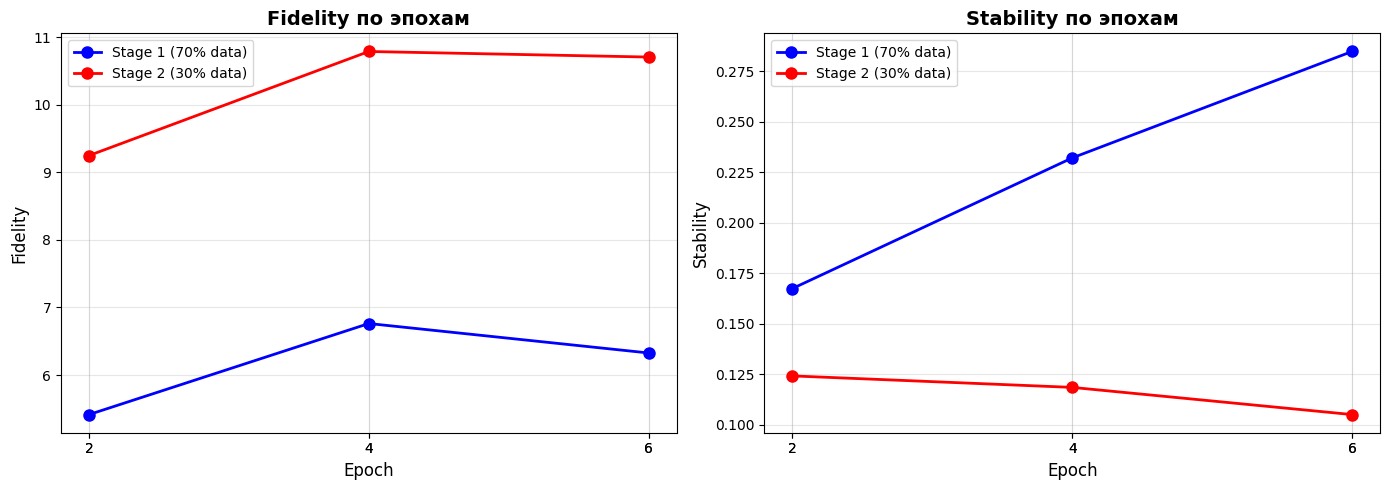

Charts are in metrics_plot.png


In [31]:
with open("stage1_full_log.json", "r", encoding="utf-8") as f:
    logs_s1 = json.load(f)
with open("stage2_full_log.json", "r", encoding="utf-8") as f:
    logs_s2 = json.load(f)

epochs_s1 = [e["epoch"] for e in logs_s1 if "fidelity" in e]
fid_s1 = [e["fidelity"] for e in logs_s1 if "fidelity" in e]
stab_s1 = [e["stability"] for e in logs_s1 if "stability" in e]

epochs_s2 = [e["epoch"] for e in logs_s2 if "fidelity" in e]
fid_s2 = [e["fidelity"] for e in logs_s2 if "fidelity" in e]
stab_s2 = [e["stability"] for e in logs_s2 if "stability" in e]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_s1, fid_s1, 'bo-', label='Stage 1 (70% data)', linewidth=2, markersize=8)
axes[0].plot(epochs_s2, fid_s2, 'ro-', label='Stage 2 (30% data)', linewidth=2, markersize=8)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Fidelity', fontsize=12)
axes[0].set_title('Fidelity по эпохам', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)
axes[0].set_xticks(epochs_s1 + epochs_s2)

axes[1].plot(epochs_s1, stab_s1, 'bo-', label='Stage 1 (70% data)', linewidth=2, markersize=8)
axes[1].plot(epochs_s2, stab_s2, 'ro-', label='Stage 2 (30% data)', linewidth=2, markersize=8)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Stability', fontsize=12)
axes[1].set_title('Stability по эпохам', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)
axes[1].set_xticks(epochs_s1 + epochs_s2)

plt.tight_layout()
plt.savefig("metrics_plot.png", dpi=300, bbox_inches='tight')
plt.show()
print("Charts are in metrics_plot.png")


Image index: 235
True class: 9
Predictes class: 9 (probability: 1.0000)


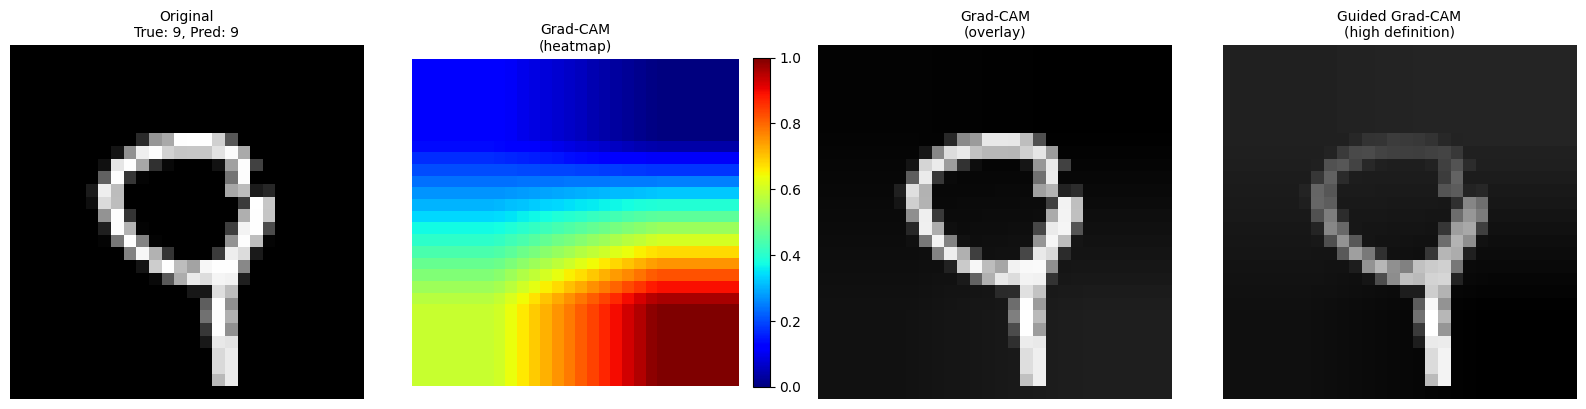


 Visualisation in gradcam_example_test_235.png


In [33]:
np.random.seed(SEED)
test_idx = np.random.randint(0, len(test_dataset))
img_tensor, true_label = test_dataset[test_idx]

img_batch = img_tensor.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    logits = model(img_batch)
    pred_class = logits.argmax(dim=1).item()
    pred_prob = F.softmax(logits, dim=1)[0, pred_class].item()

classes = list(range(10))

print(f"Image index: {test_idx}")
print(f"True class: {true_label}")
print(f"Predictes class: {pred_class} (probability: {pred_prob:.4f})")

gradcam = GradCAM(model, model.layer3[-1])
heatmap, _ = gradcam.generate(img_batch, target_class=pred_class)
gradcam.f_handle.remove()
gradcam.b_handle.remove()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img_tensor.squeeze(), cmap='gray')
axes[0].set_title(f"Original\nTrue: {true_label}, Pred: {pred_class}", fontsize=10)
axes[0].axis('off')

im1 = axes[1].imshow(heatmap, cmap='jet')
axes[1].set_title("Grad-CAM\n(heatmap)", fontsize=10)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

img_np = img_tensor.squeeze().cpu().numpy()
overlay = 0.7 * img_np + 0.3 * heatmap
im2 = axes[2].imshow(overlay, cmap='gray')
axes[2].set_title("Grad-CAM\n(overlay)", fontsize=10)
axes[2].axis('off')

guided_gradcam = img_np * heatmap
im3 = axes[3].imshow(guided_gradcam, cmap='gray')
axes[3].set_title("Guided Grad-CAM\n(high definition)", fontsize=10)
axes[3].axis('off')

plt.tight_layout()
plt.savefig(f"gradcam_example_test_{test_idx}.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Visualisation in gradcam_example_test_{test_idx}.png")